
Loading TOS  |  lat [-90, -60)
Historical: 55 model sets
  MPI-ESM1-2-HR [r1i1p1f1] — 1 file(s):
    tos_Omon_MPI-ESM1-2-HR_historical_r1i1p1f1_gn_185001-201412_ANT.nc
  55 models with valid baseline

  --- SSP1-2.6 ---
  33 model sets found
  MPI-ESM1-2-HR [r1i1p1f1] — 1 file(s):
    tos_Omon_MPI-ESM1-2-HR_ssp126_r1i1p1f1_gn_201501-210012_ANT.nc
  → 28 ensemble + 4 focus

  --- SSP3-7.0 ---
  21 model sets found
  MPI-ESM1-2-HR [r1i1p1f1] — 18 file(s):
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_201501-201912.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_202001-202412.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_202501-202912.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_203001-203412.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_203501-203912.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_204001-204412.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_204501-204912.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i1p1f1_gn_205001-205412.nc
    tos_Omon_MPI-ESM1-2-HR_ssp370_r1i

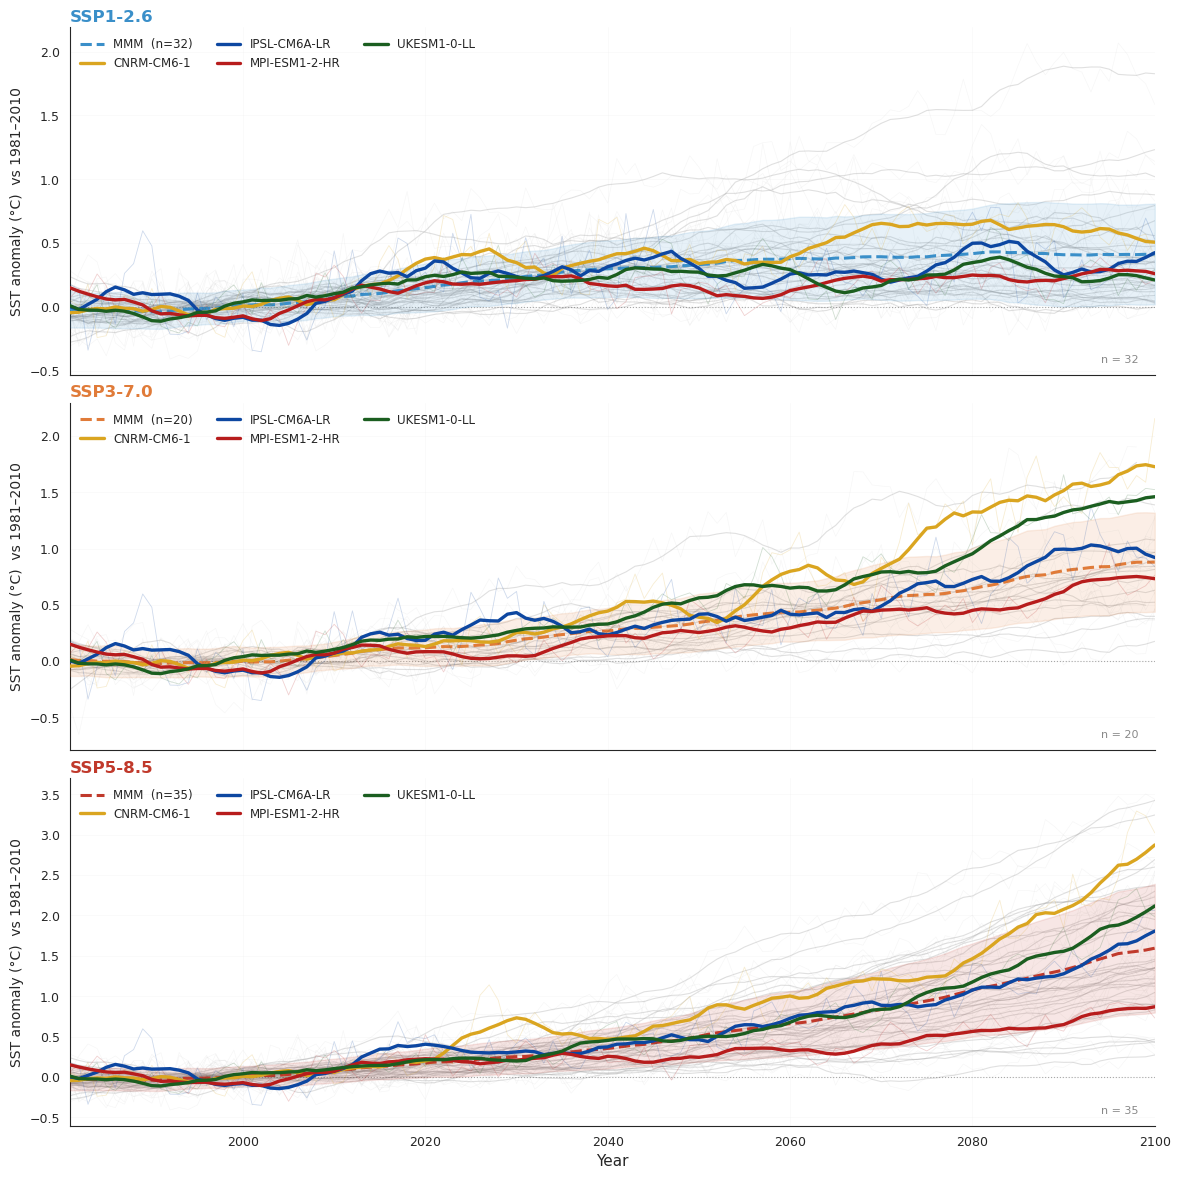

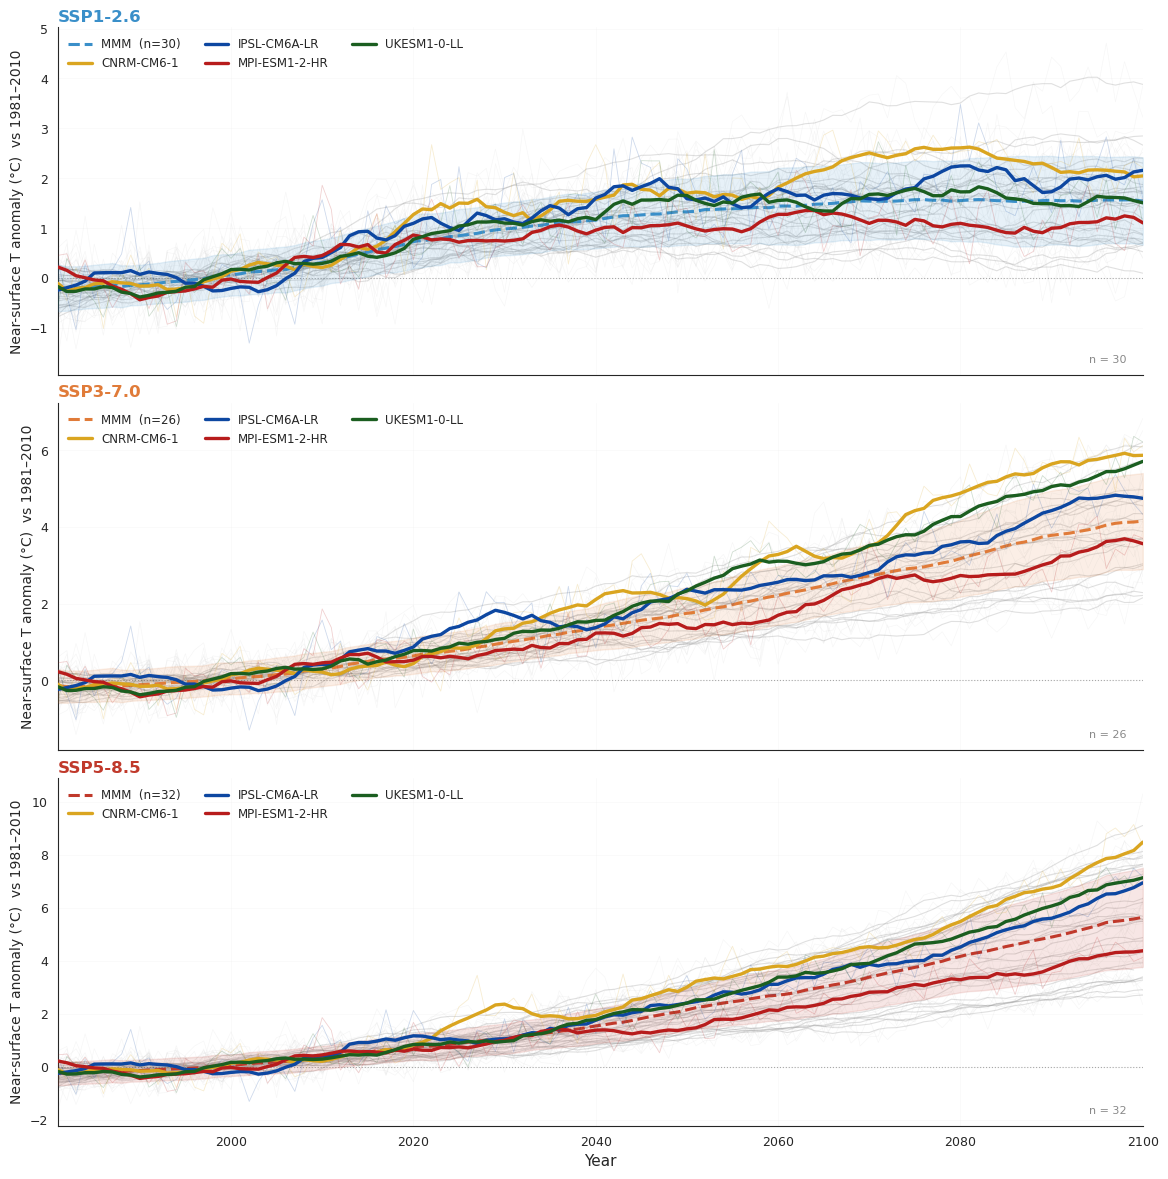

In [ ]:
# CMIP6 Antarctic SST + TAS anomaly time series
# Scenarios: ssp126, ssp370, ssp585
# SST : south of 60S  (ocean)
# TAS : south of 70S  (area-weighted)
# Anomaly relative to 1981–2010


import os, gc, glob, re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import defaultdict

sns.set_style("white")
matplotlib.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.10,
    'grid.linewidth':    0.6,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})


SST_SOURCE = '/Users/dashakan/Desktop/ANT_CMIP6_COPY'
TAS_SOURCE = '/Users/dashakan/Desktop/nearsurftemp'

LAT_SST  = -60    
LAT_TAS  = -70    
REF      = (1981, 2010)
#SMOOTH_N = 10

SCENARIOS = ['ssp126', 'ssp370', 'ssp585']

SCENARIO_LABELS = {
    'ssp126': 'SSP1-2.6',
    'ssp370': 'SSP3-7.0',
    'ssp585': 'SSP5-8.5',
}

SCEN_COLORS = {
    'ssp126': '#3A8FC9',
    'ssp370': '#E07B39',
    'ssp585': '#C0392B',
}

FOCUS_COLORS = {
    'UKESM1-0-LL'  : '#1B5E20',
    'CNRM-CM6-1'   : '#DAA520',
    'MPI-ESM1-2-HR': '#B71C1C',
    'IPSL-CM6A-LR' : '#0D47A1',
}

BAD_FILES = [
    'AWI-CM-1-1-MR', 'CAS-ESM2-0', 'CanESM5-CanOE',
    'CMCC-ESM2', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1',
    'AWI-ESM-1-1-LR', 'ICON-ESM-LR',
]

MEMBER_PRIORITY = [
    'r1i1p1f1', 'r1i1p1f2', 'r1i1p2f1', 'r1i1p2f2', 'r1i1p1f3',
]



def cmip_time_range(f):
    """Extract (start_yyyymm, end_yyyymm) from a CMIP6 filename."""
    base = os.path.basename(f)
    m = re.search(r'_(\d{6})-(\d{6})(?:_[^_]*)?\.nc$', base)
    if m is None:
        return (999999, 999999)
    return int(m.group(1)), int(m.group(2))


def sort_cmip_files(files):
    return sorted(files, key=lambda f: (*cmip_time_range(f), os.path.basename(f)))


def choose_best_file_set(files):
    """
    For one model/member, pick the minimal non-overlapping
    set of files covering the full time span.
    Prefers single complete files and _ANT variants.
    """
    files = sort_cmip_files(files)
    if len(files) <= 1:
        return files

    ranges    = {f: cmip_time_range(f) for f in files}
    min_start = min(r[0] for r in ranges.values())
    max_end   = max(r[1] for r in ranges.values())

    # Single file that covers the full span
    full = [f for f, (s, e) in ranges.items()
            if s == min_start and e == max_end]
    if full:
        full = sorted(full, key=lambda f: (
            '_ANT' not in os.path.basename(f), os.path.basename(f)
        ))
        return [full[0]]

    # Multiple chunks deduplicate overlapping ranges
    unique = {}
    for f in files:
        tr = ranges[f]
        if tr not in unique:
            unique[tr] = f
        else:
            old = unique[tr]
            if '_ANT' in os.path.basename(f) and '_ANT' not in os.path.basename(old):
                unique[tr] = f

    return [unique[k] for k in sorted(unique)]


def select_best_member(file_list):
    """
    Returns {model: (list_of_files, member)}.
    All chunks for the chosen member are kept so that
    split-range models (e.g. MPI-ESM1-2-HR) are fully covered.
    """
    models = defaultdict(lambda: defaultdict(list))
    for f in file_list:
        base  = os.path.basename(f)
        parts = base.split('_')
        if len(parts) < 6:
            continue
        model  = parts[2]
        member = parts[4]
        models[model][member].append(f)

    selected = {}
    for model, members in models.items():
        if model in BAD_FILES:
            continue
        chosen = None
        for p in MEMBER_PRIORITY:
            if p in members:
                chosen = p
                break
        if chosen is None:
            chosen = sorted(members.keys())[0]
        selected[model] = (choose_best_file_set(members[chosen]), chosen)

    return selected




def spatial_mean(da, lat_min, lat_max):
    """Area-weighted mean between lat_min and lat_max."""
    lat_coord = None
    for name in ['lat', 'latitude', 'nav_lat']:
        if name in da.coords:
            lat_coord = da.coords[name].values
            break
    if lat_coord is None:
        return None, None

    lat_v = np.squeeze(lat_coord)
    if lat_v.ndim == 1:
        lon_coord = None
        for name in ['lon', 'longitude', 'nav_lon']:
            if name in da.coords:
                lon_coord = da.coords[name].values
                break
        if lon_coord is not None:
            _, lat2d = np.meshgrid(np.squeeze(lon_coord), lat_v)
        else:
            lat2d = lat_v[:, np.newaxis] * np.ones((1, da.shape[-1]))
    else:
        lat2d = lat_v

    sp    = da.shape[1:]
    lat_f = lat2d.ravel()
    msk   = (lat_f >= lat_min) & (lat_f < lat_max)
    if not np.any(msk):
        return None, None

    fidx  = np.where(msk)[0]
    j_idx = fidx // sp[1]
    i_idx = fidx % sp[1]
    w     = np.cos(np.deg2rad(lat_f[msk]))
    vals  = da.values

    ts_mo = np.full(len(da.time), np.nan)
    for t in range(len(da.time)):
        v  = vals[t][j_idx, i_idx]
        ok = np.isfinite(v) & np.isfinite(w) & (w > 0)
        if ok.sum() > 0:
            ts_mo[t] = np.nansum(v[ok] * w[ok]) / np.nansum(w[ok])

    return da.time.dt.year.values, ts_mo


def get_varkey(ds, var_name):
    if var_name in ds.data_vars:
        return var_name
    for k in ds.data_vars:
        if k.lower() == var_name.lower():
            return k
    for k in ds.data_vars:
        if var_name.lower() in k.lower():
            return k
    return None


def to_annual(ymo, tmo):
    finite = np.isfinite(tmo)
    if finite.sum() > 0 and np.nanmean(tmo[finite]) > 200:
        tmo = tmo - 273.15
    yrs = np.unique(ymo)
    ann = np.array([np.nanmean(tmo[ymo == y]) for y in yrs])
    return yrs, ann


def combine_chunks(yrs_list, ann_list):
    """Concatenate annual chunks, sort, and average duplicate years."""
    if not yrs_list:
        return None, None
    yrs = np.concatenate(yrs_list)
    ann = np.concatenate(ann_list)
    tmp = pd.DataFrame({'year': yrs, 'value': ann})
    tmp = tmp.groupby('year', as_index=False)['value'].mean()
    return tmp['year'].values, tmp['value'].values


def read_files_to_annual(files, var_name, lat_min, lat_max):
    """Read one or more NetCDF chunks  single combined annual series."""
    yrs_all, ann_all = [], []
    for fpath in files:
        try:
            with xr.open_dataset(fpath) as ds:
                varkey = get_varkey(ds, var_name)
                if varkey is None:
                    continue
                ymo, tmo = spatial_mean(ds[varkey], lat_min, lat_max)
            gc.collect()
            if ymo is None:
                continue
            yrs, ann = to_annual(ymo, tmo)
            yrs_all.append(yrs)
            ann_all.append(ann)
        except Exception as e:
            print(f"    [read error] {os.path.basename(fpath)}: {str(e)[:60]}")
    return combine_chunks(yrs_all, ann_all)


def smooth(ts, n=SMOOTH_N):
    return pd.Series(ts).rolling(n, center=True, min_periods=n // 2).mean().values




def load_variable(source_dir, var_name, lat_min, lat_max,
                  hist_pattern, fut_pattern_fn,
                  scenarios=SCENARIOS, ref=REF,
                  debug_model='MPI-ESM1-2-HR'):
    """
    Load historical baseline + future projections for one variable.

    Returns
    -------
    hist_ref : {model: float}  — reference-period mean
    hist_ts  : {model: (yrs, ann)}
    all_ts   : {scenario: {model: (yrs_plot, ano_plot)}}
    focus_ts : {scenario: {model: (yrs_plot, ano_plot)}}
    used     : {scenario: [model names]}
    """
    print(f"\n{'='*60}")
    print(f"Loading {var_name.upper()}  |  lat [{lat_min}, {lat_max})")
    print(f"{'='*60}")

    # ── Historical ──
    hist_files = sorted(glob.glob(hist_pattern))
    hist_sel   = select_best_member(hist_files)
    print(f"Historical: {len(hist_sel)} model sets")

    if debug_model in hist_sel:
        files, member = hist_sel[debug_model]
        print(f"  {debug_model} [{member}] — {len(files)} file(s):")
        for f in files:
            print(f"    {os.path.basename(f)}")

    hist_ref = {}
    hist_ts  = {}

    for model, (files, member) in hist_sel.items():
        try:
            yrs, ann = read_files_to_annual(files, var_name, lat_min, lat_max)
            if yrs is None:
                continue
            msk = (yrs >= ref[0]) & (yrs <= ref[1])
            if msk.sum() < 5:
                continue
            hist_ref[model] = float(np.nanmean(ann[msk]))
            hist_ts[model]  = (yrs, ann)
        except Exception as e:
            print(f"  [SKIP hist] {model}: {str(e)[:70]}")

    print(f"  {len(hist_ref)} models with valid baseline")

    # ── Scenarios ──
    all_ts   = {}
    focus_ts = {}
    used     = {}

    for scen in scenarios:
        print(f"\n  --- {SCENARIO_LABELS[scen]} ---")
        fut_files = sorted(glob.glob(fut_pattern_fn(scen)))
        fut_sel   = select_best_member(fut_files)
        print(f"  {len(fut_sel)} model sets found")

        if debug_model in fut_sel:
            files, member = fut_sel[debug_model]
            print(f"  {debug_model} [{member}] — {len(files)} file(s):")
            for f in files:
                print(f"    {os.path.basename(f)}")

        ts_ens = {}
        ts_foc = {}

        for model, (files, member) in fut_sel.items():
            if model not in hist_ref:
                continue
            try:
                yrs_f, ann_f = read_files_to_annual(
                    files, var_name, lat_min, lat_max
                )
                if yrs_f is None:
                    continue

                yrs_h, ann_h = hist_ts[model]

                # historical + future
                all_yrs  = np.concatenate([yrs_h, yrs_f])
                all_vals = np.concatenate([ann_h, ann_f])
                tmp = pd.DataFrame({'year': all_yrs, 'value': all_vals})
                tmp = tmp.groupby('year', as_index=False)['value'].mean()

                all_yrs  = tmp['year'].values
                all_vals = tmp['value'].values

                ano  = all_vals - hist_ref[model]
                msk  = (all_yrs >= 1981) & (all_yrs <= 2100)
                data = (all_yrs[msk], ano[msk])

                if model in FOCUS_COLORS:
                    ts_foc[model] = data
                else:
                    ts_ens[model] = data

            except Exception as e:
                print(f"    [SKIP] {model}: {str(e)[:70]}")

        all_ts[scen]   = ts_ens
        focus_ts[scen] = ts_foc
        used[scen]     = sorted(list(ts_ens) + list(ts_foc))
        print(f"  → {len(ts_ens)} ensemble + {len(ts_foc)} focus")

    return hist_ref, hist_ts, all_ts, focus_ts, used


#load data

sst_hist_ref, sst_hist_ts, sst_all, sst_focus, sst_used = load_variable(
    source_dir     = SST_SOURCE,
    var_name       = 'tos',
    lat_min        = -90,
    lat_max        = LAT_SST,
    hist_pattern   = f"{SST_SOURCE}/*historical*r1i1*.nc",
    fut_pattern_fn = lambda scen: f"{SST_SOURCE}/*{scen}*r1i1*.nc",
)

tas_hist_ref, tas_hist_ts, tas_all, tas_focus, tas_used = load_variable(
    source_dir     = TAS_SOURCE,
    var_name       = 'tas',
    lat_min        = -90,
    lat_max        = LAT_TAS,
    hist_pattern   = f"{TAS_SOURCE}/historical/*.nc",
    fut_pattern_fn = lambda scen: f"{TAS_SOURCE}/{scen}/*.nc",
)



def print_model_table(used_dict, label):
    print(f"\n{'='*65}")
    print(f"MODELS USED — {label}")
    print(f"{'='*65}")
    all_models = sorted(set(m for ml in used_dict.values() for m in ml))
    header     = f"{'Model':<26}" + "".join(f"{SCENARIO_LABELS[s]:>12}" for s in SCENARIOS)
    print(header)
    print("─" * 62)
    for m in all_models:
        tag = '★ ' if m in FOCUS_COLORS else '  '
        row = f"{tag + m:<26}"
        for s in SCENARIOS:
            row += f"{'yes':>12}" if m in used_dict.get(s, []) else f"{'—':>12}"
        print(row)
    print(f"\n  n per scenario: { {SCENARIO_LABELS[s]: len(used_dict[s]) for s in SCENARIOS} }")

print_model_table(sst_used, f"SST (south of {abs(LAT_SST)}°S)")
print_model_table(tas_used, f"TAS (south of {abs(LAT_TAS)}°S)")



def plot_timeseries(all_ts, focus_ts, ylabel, filename,
                   domain_badge, region_note):
    
    fig, axes = plt.subplots(
        3, 1, figsize=(14, 13), sharex=True,
        gridspec_kw={'hspace': 0.08},
    )

    
    fig.text(
        0.012, 0.995, domain_badge,
        fontsize=13, fontweight='bold',
        va='top', ha='left', color='#222222',
        fontfamily='DejaVu Sans',
    )
    fig.text(
        0.012, 0.972, region_note,
        fontsize=8.5, va='top', ha='left', color='#666666',
    )

    for ax, scen in zip(axes, SCENARIOS):
        color = SCEN_COLORS[scen]
        ens   = all_ts.get(scen, {})
        foc   = focus_ts.get(scen, {})
        all_m = {**ens, **foc}

        if not all_m:
            ax.text(0.5, 0.5, f'No data — {scen}',
                    ha='center', va='center', transform=ax.transAxes)
            continue

 
        for model, (yrs, ano) in ens.items():
            ax.plot(yrs, ano,         color='#cccccc', lw=0.45, alpha=0.18, zorder=1)
            ax.plot(yrs, smooth(ano), color='#999999', lw=0.80, alpha=0.30, zorder=2)

        # MMM ± 1 std 
        all_years = np.array(sorted(
            set().union(*[set(y) for y, _ in all_m.values()])
        ))
        stacked = np.full((len(all_m), len(all_years)), np.nan)
        for i, (y, v) in enumerate(all_m.values()):
            in_range = (all_years >= y.min()) & (all_years <= y.max())
            stacked[i, in_range] = np.interp(all_years[in_range], y, v)
        n_valid = np.sum(np.isfinite(stacked), axis=0)
        mmm     = np.where(n_valid >= 3, np.nanmean(stacked, axis=0), np.nan)
        spread  = np.where(n_valid >= 3, np.nanstd(stacked,  axis=0), np.nan)

        ax.fill_between(
            all_years, smooth(mmm - spread), smooth(mmm + spread),
            color=color, alpha=0.12, zorder=3,
        )
        ax.plot(
            all_years, smooth(mmm),
            color=color, lw=2.2, ls='--', zorder=4,
            label=f'MMM  (n={len(all_m)})',
        )

        
        for model, (yrs, ano) in foc.items():
            fc = FOCUS_COLORS[model]
            ax.plot(yrs, ano,         color=fc, lw=0.6, alpha=0.20, zorder=5)
            ax.plot(yrs, smooth(ano), color=fc, lw=2.4, zorder=6, label=model)

        ax.axhline(0, color='#444444', lw=0.8, ls=':', alpha=0.45)
        ax.set_xlim(1981, 2100)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(
            SCENARIO_LABELS[scen],
            fontsize=12, fontweight='bold', color=color,
            loc='left', pad=4,
        )
        ax.legend(frameon=False, fontsize=8.5, loc='upper left', ncol=3)
        ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())

        
        ax.text(0.985, 0.03, f'n = {len(all_m)}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color='#888888')

        sns.despine(ax=ax)

    axes[-1].set_xlabel('Year', fontsize=11)
    fig.subplots_adjust(top=0.955)   
    fig.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"Saved → {filename}")
    return fig


fig_sst = plot_timeseries(
    sst_all, sst_focus,
    ylabel       = 'SST anomaly (°C)  vs 1981–2010',
    filename     = 'AIS_SST_anomaly_3scenarios.png',
    domain_badge = '',
    region_note  = f'',
)

fig_tas = plot_timeseries(
    tas_all, tas_focus,
    ylabel       = 'Near-surface T anomaly (°C)  vs 1981–2010',
    filename     = 'AIS_TAS_anomaly_3scenarios.png',
    domain_badge = '',
    region_note  = f'',
)

plt.show()